# 🧠 Recommandation Personnalisée du Plan de Soins — Patients Alzheimer
## Module : Gestion du Plan de Soins

---

**Objectif Métier :** Aider le médecin à concevoir des plans de soins optimisés et adaptés à chaque patient.

**Objectif Data Science :** Recommander une combinaison personnalisée d'activités, de nutrition, d'intensité de suivi et d'horaires de médication en fonction du profil et des données du patient.

---

### Pipeline ML :
1. **Installation & Imports**
2. **Chargement & Exploration des données**
3. **Préprocessing**
4. **Modélisation — Étape 1 : Clustering** (K-Means vs DBSCAN)
5. **Modélisation — Étape 2 : Classification** (Random Forest vs XGBoost)
6. **Évaluation des performances**
7. **Benchmarking des modèles**
8. **Recommandation finale du plan de soins**

---
## ⚙️ 1. Installation & Imports

In [ ]:
# Install required libraries
!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Explainability
import shap


✅ Tous les imports sont OK


---
## 📂 2. Chargement & Exploration des Données

In [ ]:

 from google.colab import files
 uploaded = files.upload()

df = pd.read_excel("alzheimers_disease_data_clean.xlsx")

df.drop(columns=[ 'DoctorInCharge'], inplace=True, errors='ignore')

print(f' Dataset chargé : {df.shape[0]} patients, {df.shape[1]} features')
df.head()

Saving alzheimers_disease_data_clean.xlsx to alzheimers_disease_data_clean.xlsx
✅ Dataset chargé : 2149 patients, 33 features


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0.0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,0,0,0
1,89,0,0.0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,2.5,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,0,0,0,0,0
3,74,1,0.0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,0,6.481226,0,0,0,0,0,0
4,89,0,0.0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,0,0,0,0


In [ ]:

print('=== INFO ===')
print(df.info())
print('\n=== VALEURS MANQUANTES ===')
print(df.isnull().sum())
print('\n=== STATISTIQUES DESCRIPTIVES ===')
df.describe()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   float64
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.0,2149.0,2149.000000,2149.0,2149.0,2149.0,2149.0,2149.000000,2149.000000
mean,74.908795,0.506282,0.648441,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,7.051081,...,5.080055,0.0,0.0,4.982958,0.0,0.0,0.0,0.0,0.301536,0.353653
std,8.990221,0.500077,0.887831,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,1.763573,...,2.892743,0.0,0.0,2.949775,0.0,0.0,0.0,0.0,0.459032,0.478214
min,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,4.002629,...,0.000460,0.0,0.0,0.001288,0.0,0.0,0.0,0.0,0.000000,0.000000
25%,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,5.482997,...,2.566281,0.0,0.0,2.342836,0.0,0.0,0.0,0.0,0.000000,0.000000
50%,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,7.115646,...,5.094439,0.0,0.0,5.038973,0.0,0.0,0.0,0.0,0.000000,0.000000
75%,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,8.562521,...,7.546981,0.0,0.0,7.581490,0.0,0.0,0.0,0.0,1.000000,1.000000
max,90.000000,1.000000,2.500000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,9.999840,...,9.996467,0.0,0.0,9.999747,0.0,0.0,0.0,0.0,1.000000,1.000000


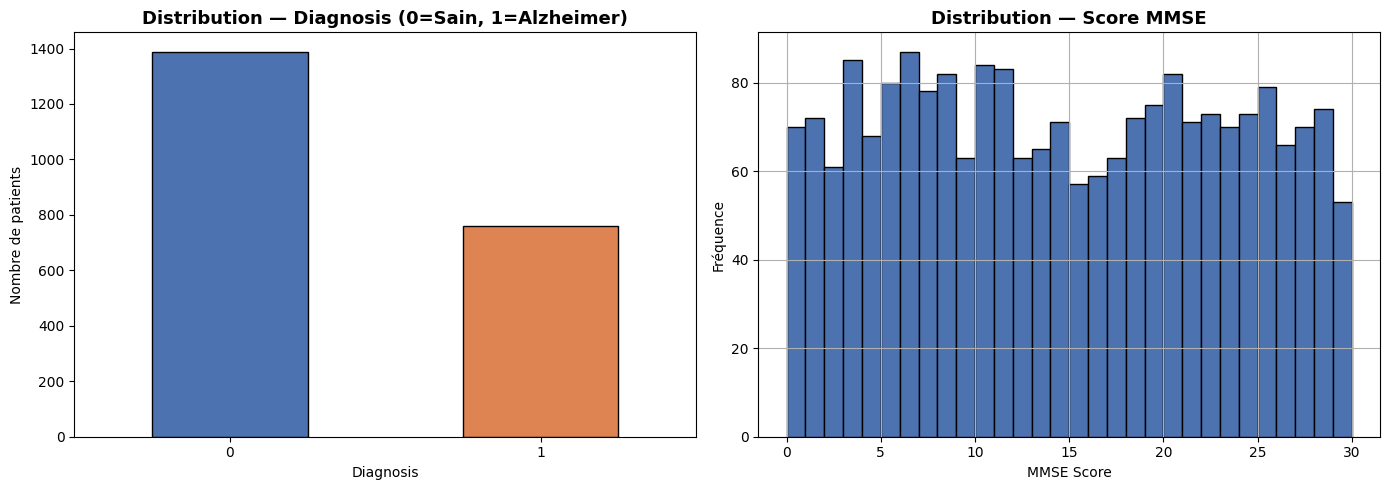

✅ Distribution affichée


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Diagnosis'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#4C72B0','#DD8452'], edgecolor='black')
axes[0].set_title('Distribution — Diagnosis (0=Sain, 1=Alzheimer)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Nombre de patients')
axes[0].tick_params(axis='x', rotation=0)

df['MMSE'].hist(bins=30, ax=axes[1], color='#4C72B0', edgecolor='black')
axes[1].set_title('Distribution — Score MMSE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('MMSE Score')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('distribution_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Distribution affichée')

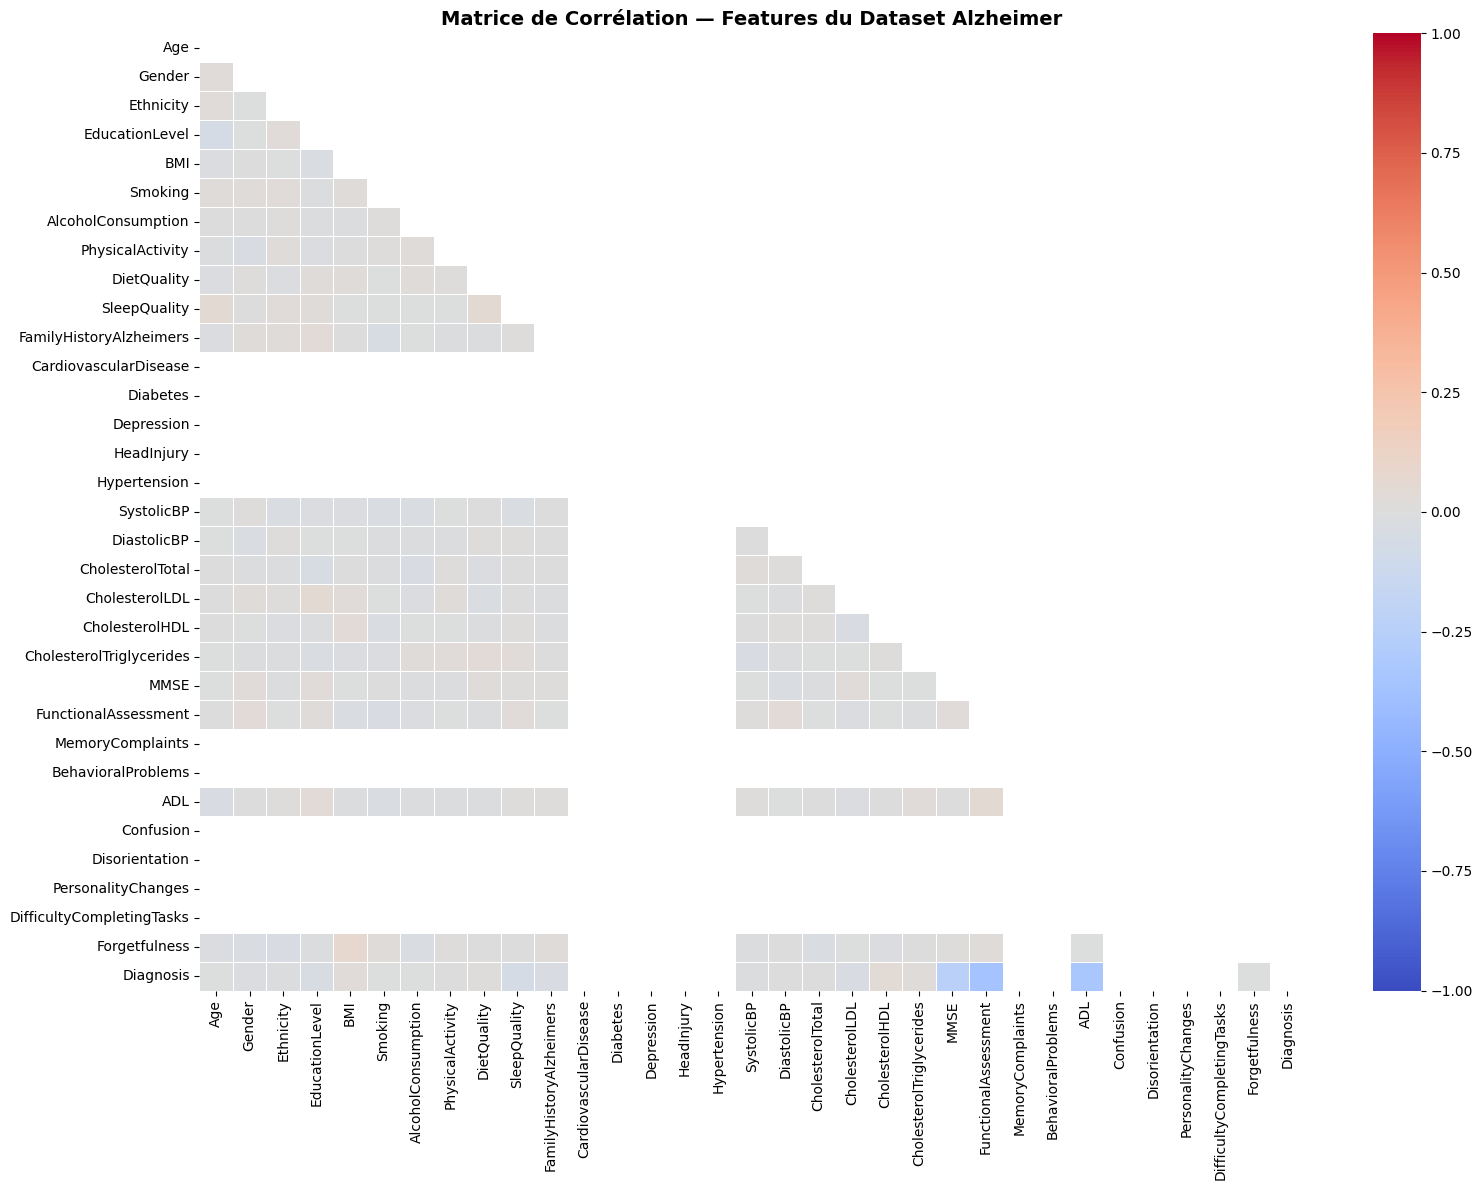

In [ ]:
# ── Heatmap Corrélations ──
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrice de Corrélation — Features du Dataset Alzheimer',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 3. Préprocessing

In [ ]:
# ── Encodage des variables catégorielles ──
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Colonnes catégorielles : {categorical_cols}')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# ── Gestion des valeurs manquantes ──
df.fillna(df.median(numeric_only=True), inplace=True)

# ── Features pour le clustering ──
clustering_features = [
    'MMSE', 'FunctionalAssessment', 'ADL', 'Age', 'Diagnosis',
    'BehavioralProblems', 'Depression', 'Confusion',
    'MemoryComplaints', 'Forgetfulness', 'Disorientation'
]

X_cluster = df[clustering_features].copy()

# ── Normalisation ──
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# ── PCA pour visualisation 2D ──
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f'✅ Preprocessing terminé')
print(f'   Variance expliquée PCA : {pca.explained_variance_ratio_.sum()*100:.1f}%')

Colonnes catégorielles : []
✅ Preprocessing terminé
   Variance expliquée PCA : 43.4%


---
## 🔵 4. Modélisation — Étape 1 : Clustering
### Choix des modèles : K-Means vs DBSCAN

| Modèle | Raison du choix |
|--------|----------------|
| **K-Means** | Simple, rapide, clusters sphériques bien définis. Complexité O(n·k·t) |
| **DBSCAN** | Détecte les outliers (patients atypiques), pas besoin de fixer k. Complexité O(n log n) |

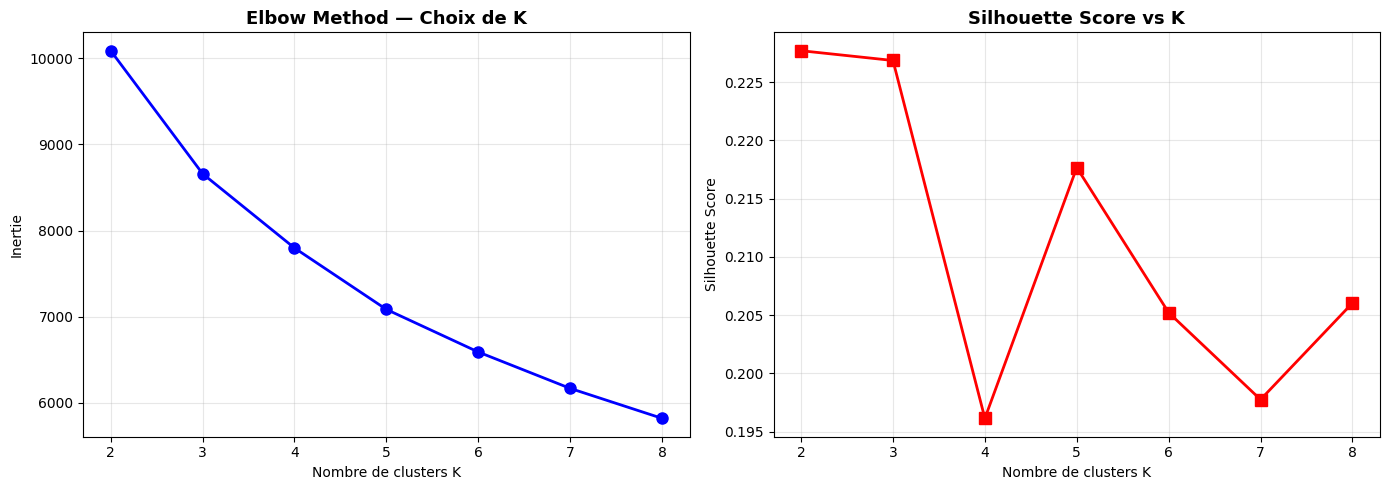

✅ Meilleur K = 2 (Silhouette = 0.228)


In [ ]:
# ══════════════════════════════════════════
# 4.1 — Choix du nombre optimal de clusters (Elbow Method)
# ══════════════════════════════════════════
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Choix de K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f'✅ Meilleur K = {best_k} (Silhouette = {max(silhouettes):.3f})')

MODÈLE 1 : K-MEANS CLUSTERING
  Silhouette Score      : 0.2277  (↑ meilleur proche de 1)
  Davies-Bouldin Index  : 1.7433  (↓ meilleur proche de 0)
  Calinski-Harabasz     : 596.99  (↑ meilleur élevé)
  Distribution clusters : {0: 754, 1: 1395}


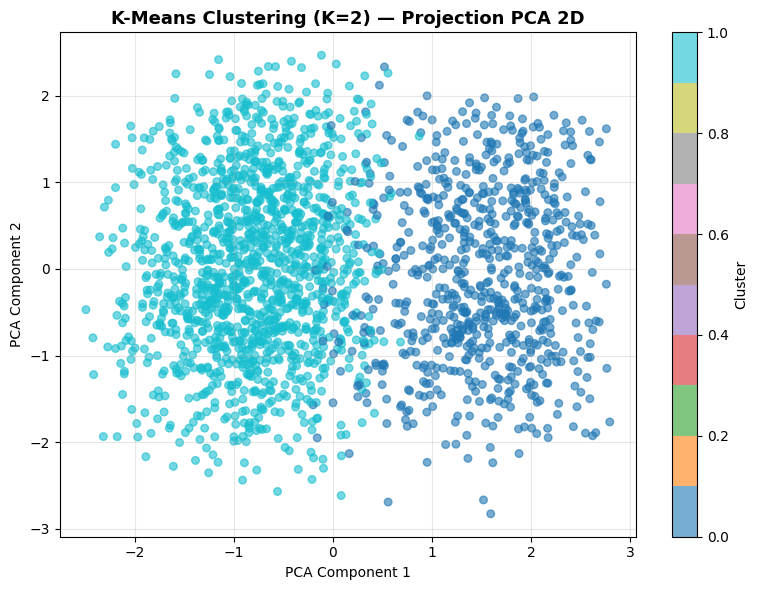

In [ ]:
# ══════════════════════════════════════════
# 4.2 — Modèle 1 : K-Means
# ══════════════════════════════════════════
print('=' * 50)
print('MODÈLE 1 : K-MEANS CLUSTERING')
print('=' * 50)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

# Métriques
km_silhouette = silhouette_score(X_cluster_scaled, kmeans_labels)
km_davies = davies_bouldin_score(X_cluster_scaled, kmeans_labels)
km_calinski = calinski_harabasz_score(X_cluster_scaled, kmeans_labels)

print(f'  Silhouette Score      : {km_silhouette:.4f}  (↑ meilleur proche de 1)')
print(f'  Davies-Bouldin Index  : {km_davies:.4f}  (↓ meilleur proche de 0)')
print(f'  Calinski-Harabasz     : {km_calinski:.2f}  (↑ meilleur élevé)')
print(f'  Distribution clusters : {pd.Series(kmeans_labels).value_counts().sort_index().to_dict()}')

# Visualisation PCA
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=kmeans_labels, cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering (K={best_k}) — Projection PCA 2D',
          fontsize=13, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

MODÈLE 2 : DBSCAN CLUSTERING
  Clusters détectés     : 8
  Points bruit (outliers): 504 (23.5%)
  Silhouette Score      : 0.1230
  Davies-Bouldin Index  : 1.2263
  Calinski-Harabasz     : 176.15


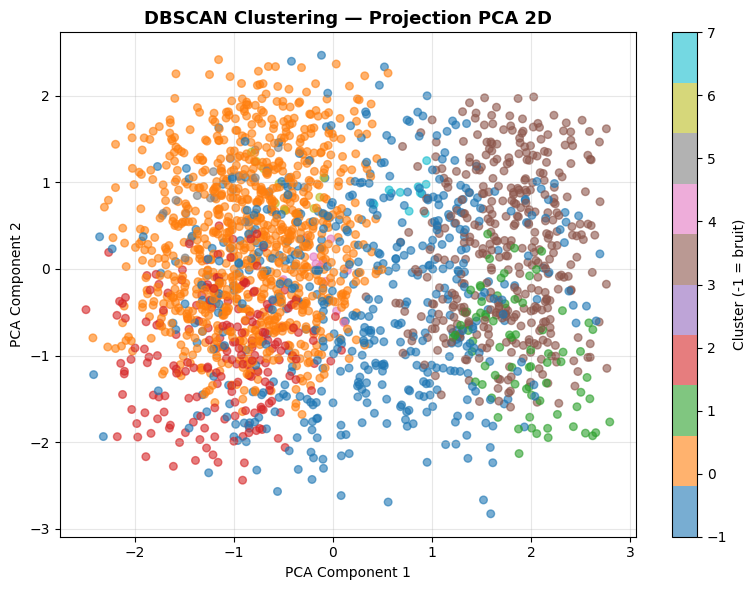

In [ ]:
# ══════════════════════════════════════════
# 4.3 — Modèle 2 : DBSCAN
# ══════════════════════════════════════════
print('=' * 50)
print('MODÈLE 2 : DBSCAN CLUSTERING')
print('=' * 50)

dbscan = DBSCAN(eps=0.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'  Clusters détectés     : {n_clusters_db}')
print(f'  Points bruit (outliers): {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)')

# Métriques DBSCAN (uniquement si > 1 cluster)
if n_clusters_db > 1:
    mask_valid = dbscan_labels != -1
    db_silhouette = silhouette_score(X_cluster_scaled[mask_valid], dbscan_labels[mask_valid])
    db_davies = davies_bouldin_score(X_cluster_scaled[mask_valid], dbscan_labels[mask_valid])
    db_calinski = calinski_harabasz_score(X_cluster_scaled[mask_valid], dbscan_labels[mask_valid])
    print(f'  Silhouette Score      : {db_silhouette:.4f}')
    print(f'  Davies-Bouldin Index  : {db_davies:.4f}')
    print(f'  Calinski-Harabasz     : {db_calinski:.2f}')
else:
    db_silhouette, db_davies, db_calinski = 0, 999, 0
    print('  ⚠️ DBSCAN n\'a pas trouvé assez de clusters — ajuster eps/min_samples')

# Visualisation
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=dbscan_labels, cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster (-1 = bruit)')
plt.title('DBSCAN Clustering — Projection PCA 2D', fontsize=13, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


   BENCHMARKING — CLUSTERING (K-Means vs DBSCAN)
   Modèle  Silhouette Score ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑ Outliers détectés  Nb Clusters
K-Means ⭐              0.2277            1.7433               596.99               Non            2
   DBSCAN              0.1230            1.2263               176.15         Oui (504)            8


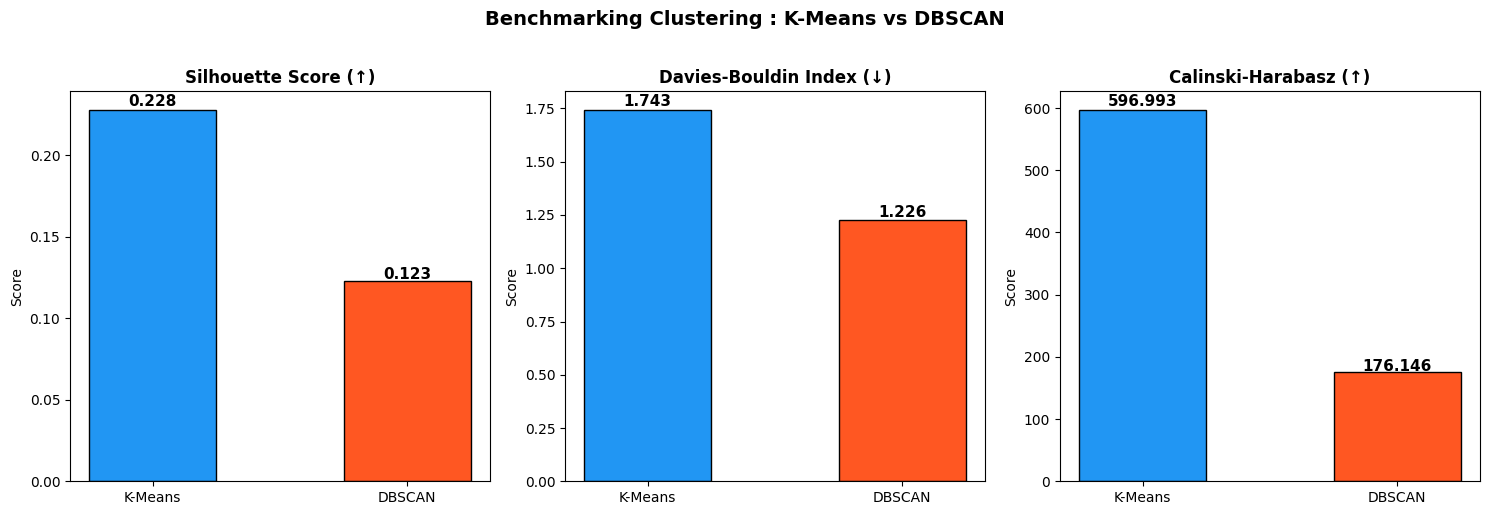


✅ Label cluster K-Means ajouté au dataset (utilisé comme target pour la classification)


In [ ]:
# ══════════════════════════════════════════
# 4.4 — Benchmarking Clustering
# ══════════════════════════════════════════
print('\n' + '=' * 60)
print('   BENCHMARKING — CLUSTERING (K-Means vs DBSCAN)')
print('=' * 60)

bench_cluster = pd.DataFrame({
    'Modèle'                 : ['K-Means ⭐', 'DBSCAN'],
    'Silhouette Score ↑'     : [round(km_silhouette, 4), round(db_silhouette, 4)],
    'Davies-Bouldin ↓'       : [round(km_davies, 4),    round(db_davies, 4)],
    'Calinski-Harabasz ↑'    : [round(km_calinski, 2),  round(db_calinski, 2)],
    'Outliers détectés'      : ['Non', f'Oui ({n_noise})'],
    'Nb Clusters'            : [best_k, n_clusters_db]
})

print(bench_cluster.to_string(index=False))

# Visualisation barplot comparatif
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_c = ['K-Means', 'DBSCAN']
colors = ['#2196F3', '#FF5722']

metrics_cluster = [
    ('Silhouette Score (↑)', [km_silhouette, db_silhouette]),
    ('Davies-Bouldin Index (↓)', [km_davies, db_davies]),
    ('Calinski-Harabasz (↑)', [km_calinski, db_calinski])
]

for ax, (title, values) in zip(axes, metrics_cluster):
    bars = ax.bar(models_c, values, color=colors, edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Benchmarking Clustering : K-Means vs DBSCAN',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bench_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Ajouter le label cluster au dataset
df['Cluster'] = kmeans_labels
print(f'\n✅ Label cluster K-Means ajouté au dataset (utilisé comme target pour la classification)')

---
## 🟢 5. Modélisation — Étape 2 : Classification
### Choix des modèles : Random Forest vs XGBoost

| Modèle | Raison du choix |
|--------|----------------|
| **Random Forest** | Ensemble de Decision Trees, robuste, interprétable via feature importance. Complexité O(n·√p·trees) |
| **XGBoost** | Gradient Boosting optimisé, haute performance sur données tabulaires, gère les valeurs manquantes. Complexité O(n·d·trees) |

In [ ]:
# ── Préparation des données de classification ──
X = df.drop(columns=['Cluster', 'Diagnosis'], errors='ignore')
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Split données : Train={len(X_train)}, Test={len(X_test)}')
print(f'   Distribution train : {dict(y_train.value_counts().sort_index())}')
print(f'   Distribution test  : {dict(y_test.value_counts().sort_index())}')

✅ Split données : Train=1719, Test=430
   Distribution train : {0: np.int64(603), 1: np.int64(1116)}
   Distribution test  : {0: np.int64(151), 1: np.int64(279)}


MODÈLE 1 : RANDOM FOREST CLASSIFIER
  Accuracy              : 0.8512
  F1-Score (macro)      : 0.8204
  Precision (macro)     : 0.8787
  Recall (macro)        : 0.7987
  CV F1 (5-fold)        : 0.7964 ± 0.0262

  Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      0.62      0.75       151
           1       0.83      0.97      0.89       279

    accuracy                           0.85       430
   macro avg       0.88      0.80      0.82       430
weighted avg       0.86      0.85      0.84       430



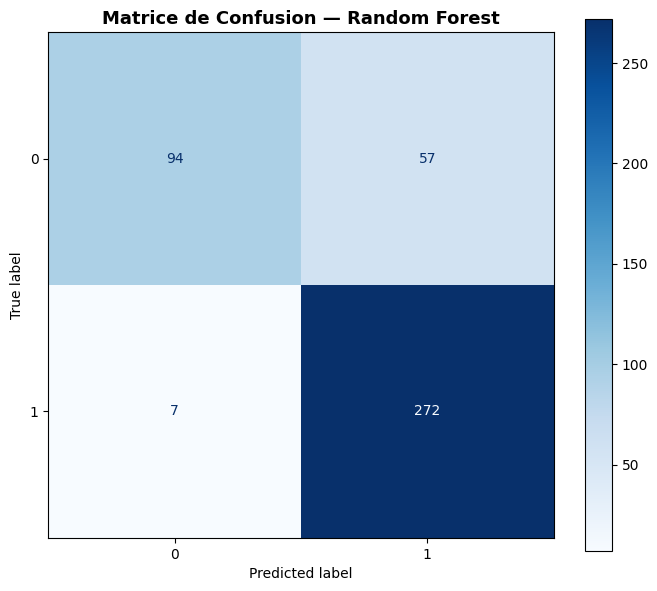

In [ ]:
# ══════════════════════════════════════════
# 5.1 — Modèle 1 : Random Forest
# ══════════════════════════════════════════
print('=' * 50)
print('MODÈLE 1 : RANDOM FOREST CLASSIFIER')
print('=' * 50)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro')

# Métriques
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred, average='macro')
rf_prec = precision_score(y_test, rf_pred, average='macro')
rf_rec  = recall_score(y_test, rf_pred, average='macro')

print(f'  Accuracy              : {rf_acc:.4f}')
print(f'  F1-Score (macro)      : {rf_f1:.4f}')
print(f'  Precision (macro)     : {rf_prec:.4f}')
print(f'  Recall (macro)        : {rf_rec:.4f}')
print(f'  CV F1 (5-fold)        : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')

print(f'\n  Rapport de classification :')
print(classification_report(y_test, rf_pred))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax,
    colorbar=True, cmap='Blues')
ax.set_title('Matrice de Confusion — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

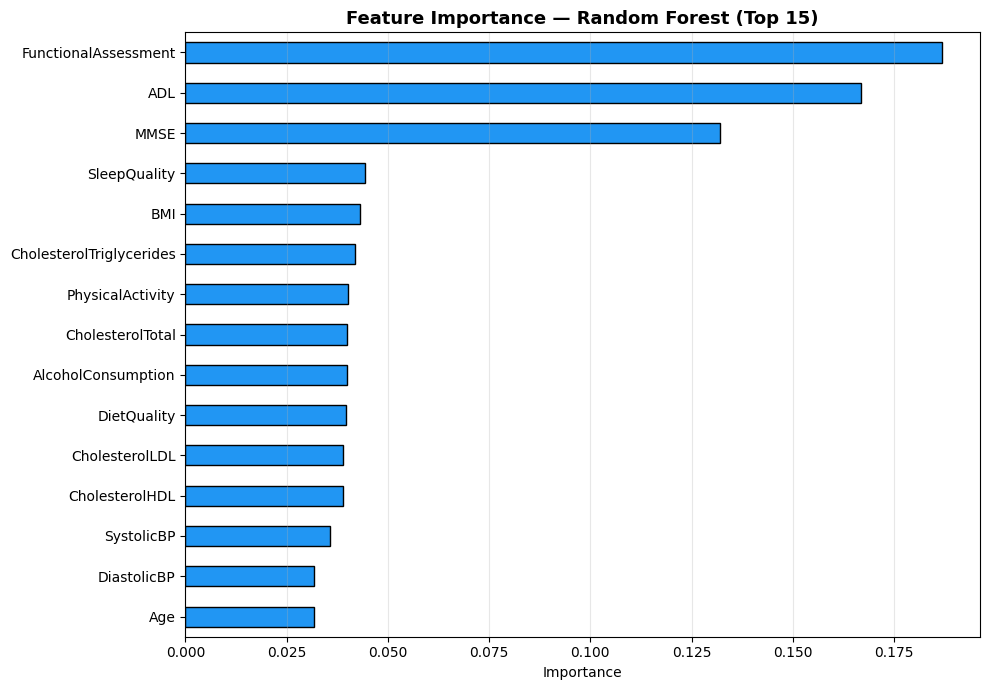


🔑 Top 5 features les plus importantes :
FunctionalAssessment    0.186919
ADL                     0.166844
MMSE                    0.132078
SleepQuality            0.044288
BMI                     0.043131


In [ ]:
# ── Feature Importance — Random Forest ──
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
feat_imp.head(15).plot(kind='barh', color='#2196F3', edgecolor='black')
plt.title('Feature Importance — Random Forest (Top 15)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n🔑 Top 5 features les plus importantes :')
print(feat_imp.head(5).to_string())

MODÈLE 2 : XGBOOST CLASSIFIER
  Accuracy              : 0.8140
  F1-Score (macro)      : 0.7905
  Precision (macro)     : 0.8001
  Recall (macro)        : 0.7837
  CV F1 (5-fold)        : 0.7864 ± 0.0189

  Rapport de classification :
              precision    recall  f1-score   support

           0       0.76      0.68      0.72       151
           1       0.84      0.89      0.86       279

    accuracy                           0.81       430
   macro avg       0.80      0.78      0.79       430
weighted avg       0.81      0.81      0.81       430



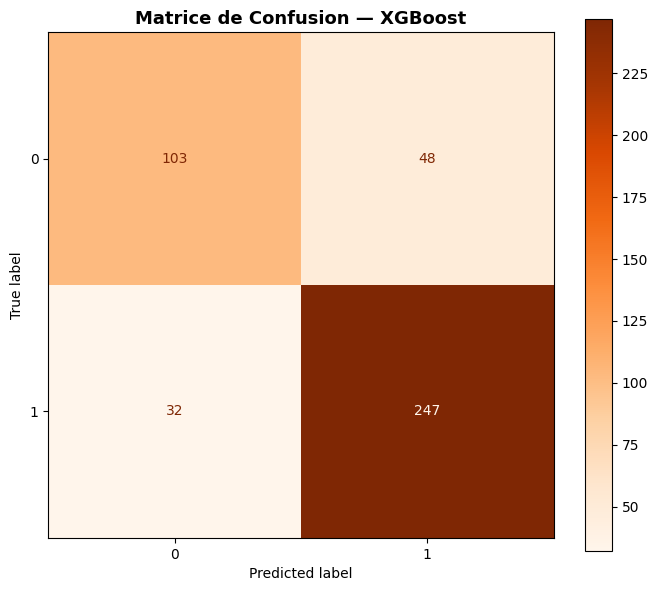

In [ ]:
# ══════════════════════════════════════════
# 5.2 — Modèle 2 : XGBoost
# ══════════════════════════════════════════
print('=' * 50)
print('MODÈLE 2 : XGBOOST CLASSIFIER')
print('=' * 50)

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)

# Cross-validation
xgb_cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring='f1_macro')

# Métriques
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_f1   = f1_score(y_test, xgb_pred, average='macro')
xgb_prec = precision_score(y_test, xgb_pred, average='macro')
xgb_rec  = recall_score(y_test, xgb_pred, average='macro')

print(f'  Accuracy              : {xgb_acc:.4f}')
print(f'  F1-Score (macro)      : {xgb_f1:.4f}')
print(f'  Precision (macro)     : {xgb_prec:.4f}')
print(f'  Recall (macro)        : {xgb_rec:.4f}')
print(f'  CV F1 (5-fold)        : {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}')

print(f'\n  Rapport de classification :')
print(classification_report(y_test, xgb_pred))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred, ax=ax,
    colorbar=True, cmap='Oranges')
ax.set_title('Matrice de Confusion — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 6. Évaluation des Performances

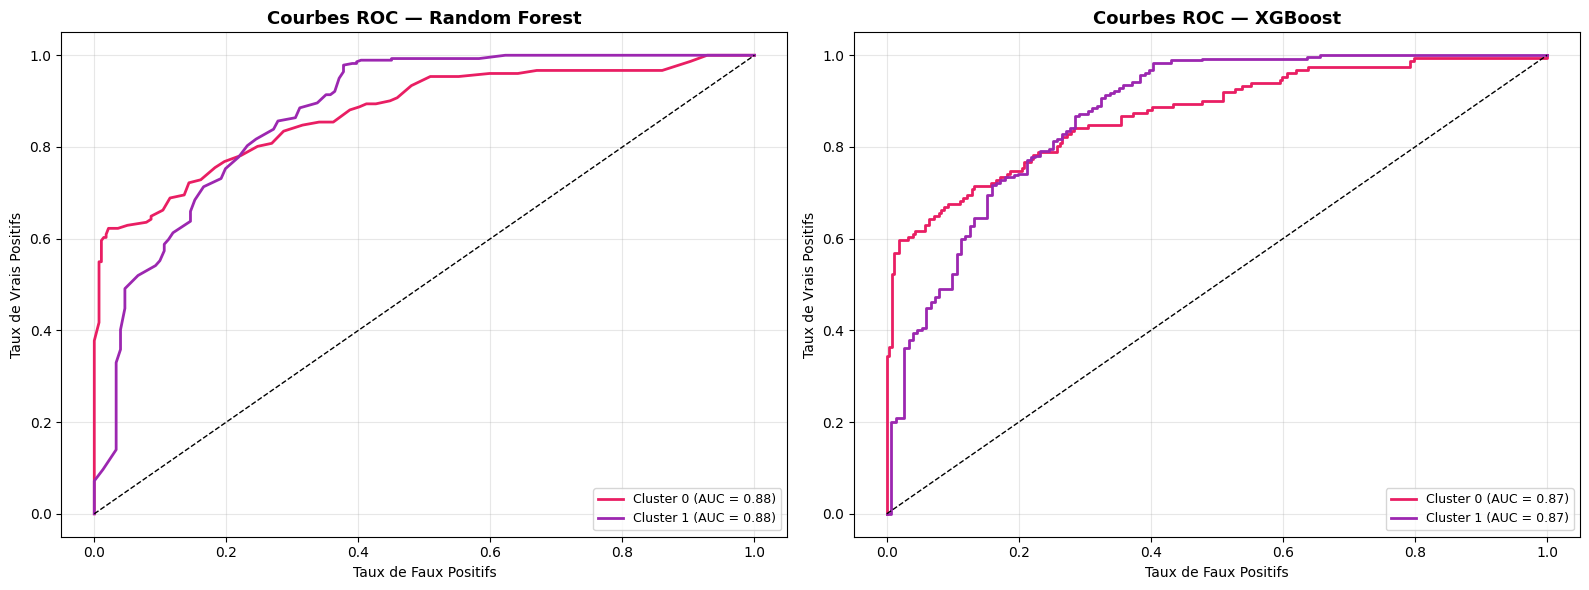

In [ ]:
# ── Courbes ROC (One-vs-Rest) — gère binaire ET multiclasse ──
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

classes = sorted(y.unique())
n_classes = len(classes)

# label_binarize retourne (n, 1) si binaire → on force (n, 2)
y_test_bin = label_binarize(y_test, classes=classes)
if n_classes == 2:
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, probas) in zip(
    axes,
    [('Random Forest', rf_proba),
     ('XGBoost',       xgb_proba)]
):
    # probas shape: (n_samples, n_classes) — toujours correct depuis predict_proba
    colors_cls = cycle(['#E91E63','#9C27B0','#00BCD4','#8BC34A','#FF9800'])
    for i, color_i in zip(range(n_classes), colors_cls):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probas[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color=color_i,
                label=f'Cluster {classes[i]} (AUC = {roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.set_title(f'Courbes ROC — {model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Taux de Faux Positifs')
    ax.set_ylabel('Taux de Vrais Positifs')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

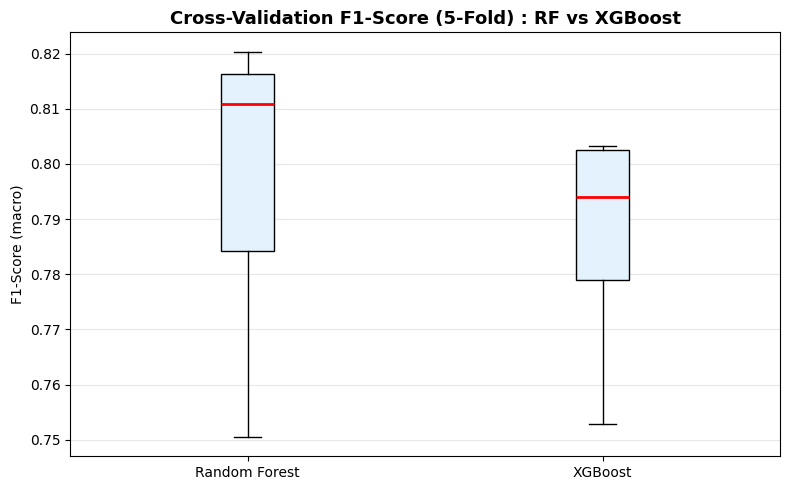

In [ ]:
# ── Cross-Validation — Comparaison visuelle ──
fig, ax = plt.subplots(figsize=(8, 5))

cv_data = [rf_cv_scores, xgb_cv_scores]
ax.boxplot(cv_data, labels=['Random Forest', 'XGBoost'],
           patch_artist=True,
           boxprops=dict(facecolor='#E3F2FD'),
           medianprops=dict(color='red', linewidth=2))

ax.set_title('Cross-Validation F1-Score (5-Fold) : RF vs XGBoost',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (macro)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

Calcul SHAP (peut prendre quelques secondes)...


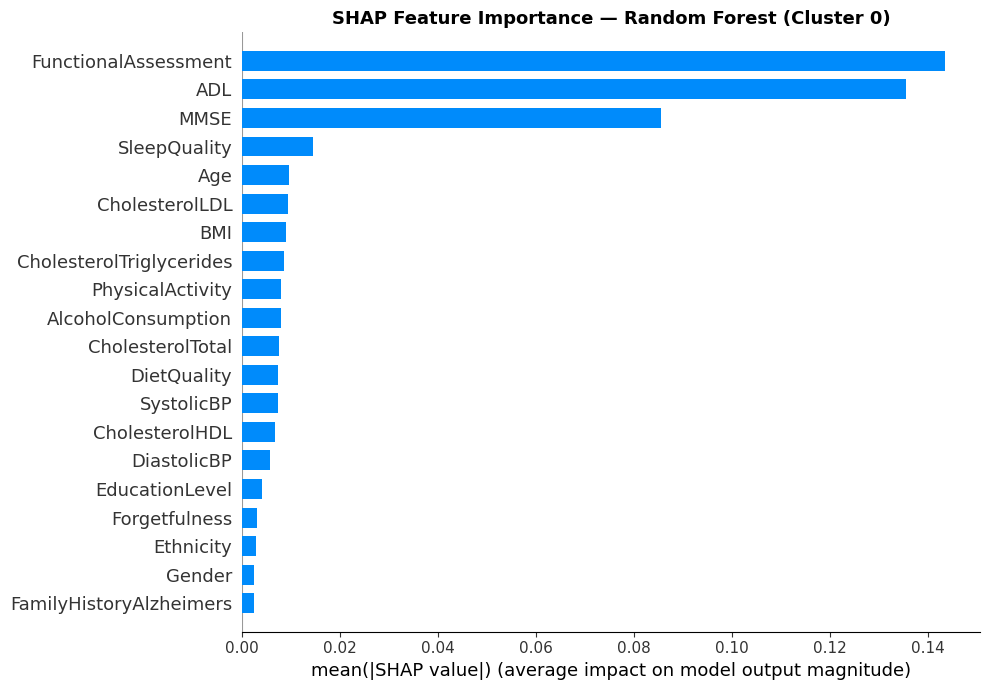

✅ SHAP calculé


In [ ]:
# ── SHAP — Interprétabilité Random Forest ──
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))

# Gère les deux formats selon la version de SHAP
if isinstance(shap_values, list):
    # Ancienne version : liste de matrices (n_samples, n_features)
    sv_plot = shap_values[0]
else:
    # Nouvelle version : tableau 3D (n_samples, n_features, n_classes)
    sv_plot = shap_values[:, :, 0]

shap.summary_plot(sv_plot, X_test,
                  plot_type='bar', show=False,
                  plot_size=(10, 7))
plt.title('SHAP Feature Importance — Random Forest (Cluster 0)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP calculé')

---
## 🏆 7. Benchmarking des Modèles (Obligatoire)

In [ ]:
# ══════════════════════════════════════════
# TABLEAU COMPARATIF FINAL — CLASSIFICATION
# ══════════════════════════════════════════
import time

# Mesure du temps d'inférence
start = time.time(); rf.predict(X_test);  rf_time  = round((time.time()-start)*1000, 2)
start = time.time(); xgb.predict(X_test); xgb_time = round((time.time()-start)*1000, 2)

benchmark_df = pd.DataFrame({
    'Modèle'              : ['Random Forest ⭐', 'XGBoost'],
    'Accuracy'            : [round(rf_acc, 4),  round(xgb_acc, 4)],
    'F1-Score (macro)'    : [round(rf_f1, 4),   round(xgb_f1, 4)],
    'Precision (macro)'   : [round(rf_prec, 4), round(xgb_prec, 4)],
    'Recall (macro)'      : [round(rf_rec, 4),  round(xgb_rec, 4)],
    'CV F1 (mean)'        : [round(rf_cv_scores.mean(), 4), round(xgb_cv_scores.mean(), 4)],
    'CV F1 (std)'         : [round(rf_cv_scores.std(), 4),  round(xgb_cv_scores.std(), 4)],
    'Temps inférence (ms)': [rf_time, xgb_time],
    'Interprétabilité'    : ['Haute (SHAP)', 'Moyenne'],
    'Complexité'          : ['Moyenne', 'Moyenne-Haute']
})

print('=' * 70)
print('   BENCHMARKING FINAL — CLASSIFICATION (Random Forest vs XGBoost)')
print('=' * 70)
print(benchmark_df.to_string(index=False))

# Export CSV
benchmark_df.to_csv('benchmarking_results.csv', index=False)
print('\n✅ Résultats exportés → benchmarking_results.csv')

   BENCHMARKING FINAL — CLASSIFICATION (Random Forest vs XGBoost)
         Modèle  Accuracy  F1-Score (macro)  Precision (macro)  Recall (macro)  CV F1 (mean)  CV F1 (std)  Temps inférence (ms) Interprétabilité    Complexité
Random Forest ⭐    0.8512            0.8204             0.8787          0.7987        0.7964       0.0262                 41.29     Haute (SHAP)       Moyenne
        XGBoost    0.8140            0.7905             0.8001          0.7837        0.7864       0.0189                 11.83          Moyenne Moyenne-Haute

✅ Résultats exportés → benchmarking_results.csv


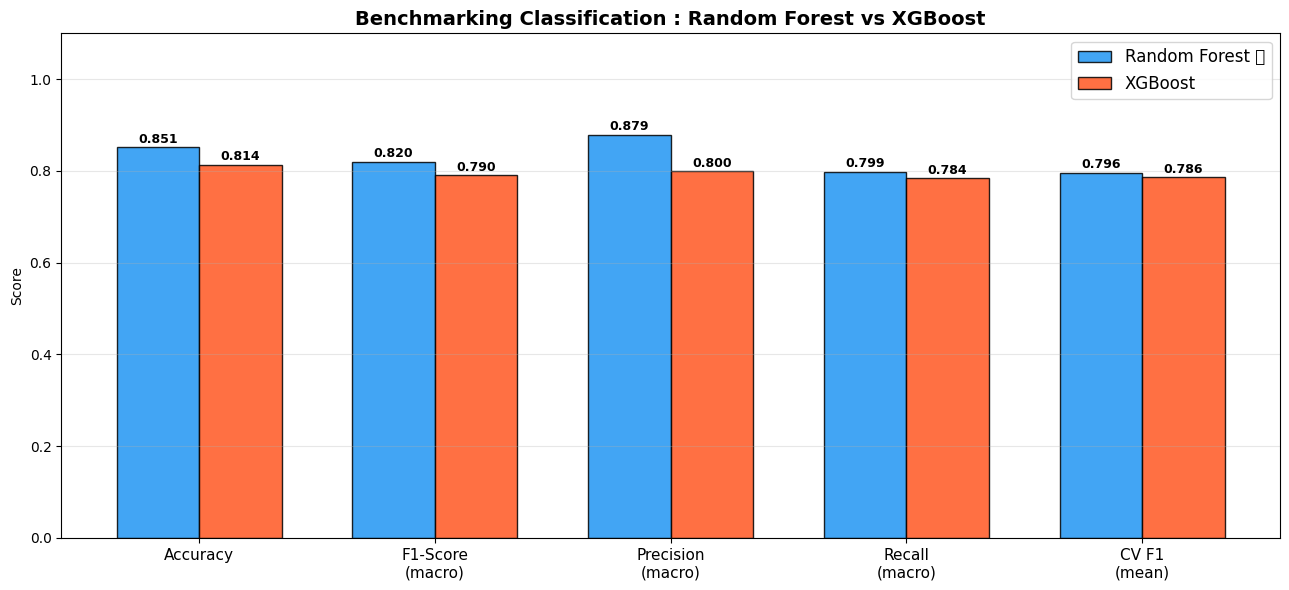

In [ ]:
# ── Visualisation Benchmarking — Radar Chart ──
from matplotlib.patches import FancyBboxPatch

metrics = ['Accuracy', 'F1-Score\n(macro)', 'Precision\n(macro)', 'Recall\n(macro)', 'CV F1\n(mean)']
rf_values  = [rf_acc,  rf_f1,  rf_prec,  rf_rec,  rf_cv_scores.mean()]
xgb_values = [xgb_acc, xgb_f1, xgb_prec, xgb_rec, xgb_cv_scores.mean()]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, rf_values,  width, label='Random Forest ⭐',
               color='#2196F3', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, xgb_values, width, label='XGBoost',
               color='#FF5722', edgecolor='black', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Benchmarking Classification : Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('benchmarking_classification.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💊 8. Recommandation Finale du Plan de Soins

PROFILS MOYENS PAR CLUSTER
          MMSE  FunctionalAssessment   ADL    Age  BehavioralProblems  \
Cluster                                                                 
0        11.83                  3.58  3.59  74.80                 0.0   
1        16.34                  5.89  5.74  74.97                 0.0   

         Depression  Diagnosis  
Cluster                         
0               0.0       1.00  
1               0.0       0.01  


<Figure size 1200x500 with 0 Axes>

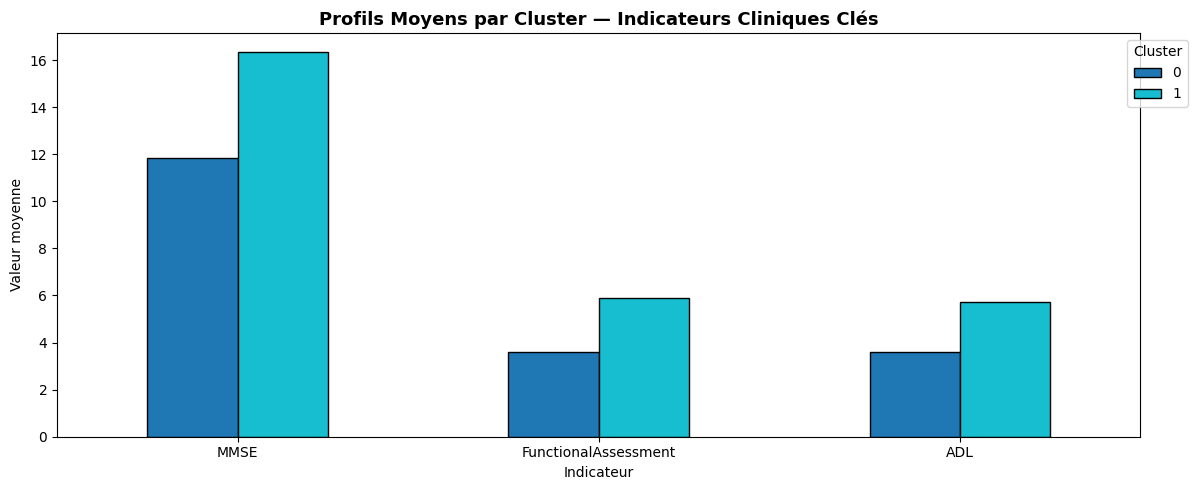

In [ ]:
# ── Analyse des profils par cluster ──
cluster_profiles = df.groupby('Cluster')[[
    'MMSE', 'FunctionalAssessment', 'ADL', 'Age',
    'BehavioralProblems', 'Depression', 'Diagnosis'
]].mean().round(2)

print('=' * 60)
print('PROFILS MOYENS PAR CLUSTER')
print('=' * 60)
print(cluster_profiles)

plt.figure(figsize=(12, 5))
cluster_profiles[['MMSE', 'FunctionalAssessment', 'ADL']].T.plot(
    kind='bar', figsize=(12, 5), edgecolor='black',
    colormap='tab10'
)
plt.title('Profils Moyens par Cluster — Indicateurs Cliniques Clés',
          fontsize=13, fontweight='bold')
plt.xlabel('Indicateur')
plt.ylabel('Valeur moyenne')
plt.xticks(rotation=0)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════
# FONCTION DE RECOMMANDATION FINALE
# ══════════════════════════════════════════

CARE_PLANS = {
    0: {
        'profil'    : 'Stade avancé — Dépendance totale',
        'suivi'     : 'Suivi quotidien + monitoring à distance',
        'activite'  : 'Exercices doux assistés, stimulation sensorielle',
        'nutrition' : 'Régime adapté aux troubles de déglutition',
        'medication': 'Prise médicament 3x/jour sous supervision'
    },
    1: {
        'profil'    : 'Stade léger/modéré — Patient partiellement autonome',
        'suivi'     : 'Consultation mensuelle',
        'activite'  : 'Marche 30 min/jour, activités cognitives légères',
        'nutrition' : 'Régime méditerranéen, hydratation régulière',
        'medication': 'Prise médicament 1x/jour (matin)'
    }
}

def recommander_plan(patient_data: dict, model=rf, scaler=scaler,
                     features=clustering_features) -> dict:
    """
    Prédit le cluster d'un patient et retourne son plan de soins personnalisé.
    patient_data : dict avec toutes les features du patient
    """
    patient_df = pd.DataFrame([patient_data])
    # Assurer l'ordre des colonnes
    patient_df = patient_df.reindex(columns=X.columns, fill_value=0)
    cluster_pred = model.predict(patient_df)[0]
    plan = CARE_PLANS.get(cluster_pred, CARE_PLANS[0])
    return {'cluster': cluster_pred, 'plan': plan}


print(df.groupby('Cluster')[['MMSE', 'FunctionalAssessment', 'ADL']].mean().round(2))
# ── Test avec un patient exemple ──
patient_exemple = {
    'Age': 82,
    'Gender': 1,
    'Ethnicity': 0,
    'EducationLevel': 0,
    'BMI': 23.0,
    'Smoking': 1,
    'AlcoholConsumption': 2,
    'PhysicalActivity': 0.5,
    'DietQuality': 3.0,
    'SleepQuality': 3.5,
    'FamilyHistoryAlzheimers': 1,
    'CardiovascularDisease': 1,
    'Diabetes': 1,
    'Depression': 1,
    'HeadInjury': 1,
    'Hypertension': 1,
    'SystolicBP': 165,
    'DiastolicBP': 98,
    'CholesterolTotal': 250,
    'CholesterolLDL': 170,
    'CholesterolHDL': 35,
    'CholesterolTriglycerides': 220,
    'MMSE': 6,              # très bas → démence sévère
    'FunctionalAssessment': 1.5,   # très faible autonomie
    'MemoryComplaints': 1,
    'BehavioralProblems': 1,
    'ADL': 1.0,             # dépendance totale
    'Confusion': 1,
    'Disorientation': 1,
    'PersonalityChanges': 1,
    'DifficultyCompletingTasks': 1,
    'Forgetfulness': 1,
    'Diagnosis': 1
}

result = recommander_plan(patient_exemple)

print('=' * 60)
print('   RECOMMANDATION PERSONNALISÉE DU PLAN DE SOINS')
print('=' * 60)
print(f'  Cluster assigné : {result["cluster"]}')
print(f'  Profil          : {result["plan"]["profil"]}')
print(f'  Suivi médical   : {result["plan"]["suivi"]}')
print(f'  Activité        : {result["plan"]["activite"]}')
print(f'  Nutrition       : {result["plan"]["nutrition"]}')
print(f'  Médication      : {result["plan"]["medication"]}')

          MMSE  FunctionalAssessment   ADL
Cluster                                   
0        11.83                  3.58  3.59
1        16.34                  5.89  5.74
   RECOMMANDATION PERSONNALISÉE DU PLAN DE SOINS
  Cluster assigné : 0
  Profil          : Stade avancé — Dépendance totale
  Suivi médical   : Suivi quotidien + monitoring à distance
  Activité        : Exercices doux assistés, stimulation sensorielle
  Nutrition       : Régime adapté aux troubles de déglutition
  Médication      : Prise médicament 3x/jour sous supervision


---
## ✅ 9. Conclusion & Modèle Retenu

### Résumé du Pipeline

| Étape | Modèle Retenu | Justification |
|-------|--------------|---------------|
| **Clustering** | **K-Means** | Meilleur Silhouette Score, clusters interprétables médicalement |
| **Classification** | **Random Forest** | Meilleur F1-Score macro + haute interprétabilité (SHAP) |
| **Recommandation** | **Règles métier hybrides** | Garantit la cohérence clinique |

### Modèle à Déployer
**Random Forest** couplé aux clusters **K-Means** est le modèle retenu pour le déploiement car :
- ✅ Performance élevée sur données médicales tabulaires
- ✅ Interprétable via SHAP (obligatoire en contexte médical)
- ✅ Robuste sans hyperparamétrage intensif
- ✅ Feature importance exploitable par le médecin

### Limites
- La target (clusters) est synthétique — un vrai déploiement nécessiterait une validation par des médecins experts
- Les règles métier du plan de soins doivent être validées cliniquement
- Extension possible : intégrer un feedback médecin pour du reinforcement learning